# Projekt 1 `[20b]`

**Rozdelenie bodov:**


*   riešenie úloh `[18b]`
    *    oblasť import dát `[2b]`
    *    oblasť čistenie dát `[2b]`
    *    oblasť transformácia dát `[5b]`
    *    oblasť exploračná dátová analýza `[9b]`
*   formálna stránka odovzdaného projektu `[2b]`
    * dokumentácia
    * komentáre
    * logické členenie textu a kódu
    * vizuálna stránka




In [54]:
#!pip install vaderSentiment fast-langdetect

In [55]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from shapely import Point
from fast_langdetect import detect as lang_detect # detektor jazyka
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer as sent_analyzer # analyza sentimentu v texte
import re
import unicodedata
from collections import Counter

## 1 Import dát `[2b]`

### 1.1 Načítanie súborov `[1b]`

#### 1.1.1 Súbor `listings.csv` `[0.6b]`

Tento súbor obsahuje hlavný dataset s ubytovaniami v Prahe. Načítajte súbor ako `DataFrame`. Pretransformujte ho do `GeoDataFrame`-u. Aktívnou geometriou sa stane nový stĺpec s názvom `location`, ktorý bude predstavovať GPS súradnicu ubytovania (zemepisná dĺžka a šírka). Po vytvorení geometrického stĺpca, staré stĺpce `longitude` a `latitude` vymažte. Výsledný dataset pomenujte ako `listings`.


In [56]:
# nacitanie datasetu listings.csv ako DataFrame a nasledne pretransformovanie do GeoDataFrame-u
listings = pd.read_csv("listings.csv")

listings = gpd.GeoDataFrame(
    listings,
    geometry=gpd.points_from_xy(listings['longitude'], listings['latitude']),
    crs="EPSG:4326"
)

# premenovanie noveho stlpca geometry na location a nastavenie aktivnej geometrie 
listings = listings.rename(columns={"geometry": "location"})
listings = listings.set_geometry('location')

# vymazanie stlpcov latitude a longitude
del listings["latitude"]
del listings["longitude"]

listings

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,location
0,23163,Residence Karolina - KAROL12,5282,Klara,NaN,Praha 1,Entire home/apt,NaN,1,31,2024-06-15,0.17,75,0,0,NaN,POINT (14.41552 50.08229)
1,23169,Residence Masna - Masna302,5282,Klara,NaN,Praha 1,Entire home/apt,NaN,1,124,2025-06-25,0.66,75,14,3,NaN,POINT (14.42272 50.0883)
2,26755,Central Prague Old Town Top Floor,113902,Daniel+Bea,NaN,Praha 1,Entire home/apt,2272.0,3,440,2025-09-06,3.49,3,142,54,NaN,POINT (14.43179 50.08729)
3,30762,Residence Rybna - Rybna23,5282,Klara,NaN,Praha 1,Entire home/apt,NaN,1,17,2025-05-06,0.10,75,25,1,NaN,POINT (14.42623 50.08821)
4,42514,"""NEWLY FURNISHED"" 1BR near Pachtuv Palace,Old ...",185641,Victoria,NaN,Praha 1,Entire home/apt,2885.0,7,333,2023-04-30,1.81,1,362,0,NaN,POINT (14.41345 50.08228)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10829,1515809052516808785,"Cozy flat w/ Balcony&Parking, near Metro & Centre",176252442,Artur,NaN,Praha 13,Entire home/apt,1715.0,1,0,NaN,NaN,1,324,0,NaN,POINT (14.34517 50.05088)
10830,1515820376391468787,Peaceful Apartment next to Jubilee Synagogue,227945,Alex And Kate,NaN,Praha 1,Entire home/apt,2186.0,2,0,NaN,NaN,95,61,0,NaN,POINT (14.43119 50.08403)
10831,1515865729897302482,Apartment Spalená,314317287,Tommy,NaN,Praha 1,Private room,2328.0,2,0,NaN,NaN,2,82,0,NaN,POINT (14.41929 50.08185)
10832,1515888570117465214,Fresh Apartment next to Prague City Center at ...,523424457,Rentero,NaN,Praha 7,Entire home/apt,26608.0,2,0,NaN,NaN,39,89,0,NaN,POINT (14.45336 50.10319)


#### 1.1.2 Súbor `reviews.csv` `[0.2b]`

Tento súbor obsahuje recenzie ubytovaných hostí. Načítajte súbor ako `DataFrame`. Pomenujte ho ako `reviews`.


In [57]:
# nacitanie datasetu reviews.csv ako DataFrame
reviews = pd.read_csv("reviews.csv")

reviews

,listing_id,id,date,reviewer_id,reviewer_name,comments
0,23163,101588,2010-09-20,227165,Nathan,Incredible apartment in an ideal location. The...
1,23163,157152,2010-12-22,286036,Hugh,"The apartment was huge, we felt like we were s..."
2,23163,1512585,2012-06-18,2634312,Sergey,"Отличная квартира и сервис, большое спасибо."
3,23163,1871730,2012-08-02,2538194,Sônia,Great place to combine the good things of an a...
4,23163,24542545,2014-12-30,21860409,Rachel,Residence Karolina and Prague City Apartments ...
...,...,...,...,...,...,...
843766,1507987899909808162,1513035494998296880,2025-09-18,708724943,Ondřej,Vše bylo v naprostém pořádku. Domluva na jedn...
843767,1508619067949125349,1514491088877731763,2025-09-20,261128895,Nick,Идеальный вариант
843768,1508855912261226428,1515144343478568428,2025-09-21,435564161,Serhat,"Perfekt für Kurztrips! Die Lage ist super, der..."
843769,1512131535918395255,1515156798549008473,2025-09-21,163490900,Yll,Highly Recommended


#### 1.1.3 Súbor `neighbourhoods.geojson` `[0.2b]`

Tento súbor obsahuje jednotlivé mestské časti Prahy geograficky reprezentované polygónmi (každý bod polygónu je GPS súradnica). Načítajte súbor ako `GeoDataFrame`. Pomenujte ho ako `neighbourhoods`.


In [58]:
# nacitanie datasetu neighbourhoods.geojson ako GeoDataFrame
neighbourhoods = gpd.read_file("neighbourhoods.geojson")

neighbourhoods

,neighbourhood,neighbourhood_group,geometry
0,Praha 1,None,"MULTIPOLYGON (((14.41088 50.07867, 14.40982 50..."
1,Praha 6,None,"MULTIPOLYGON (((14.2932 50.07751, 14.29317 50...."
2,Praha 9,None,"MULTIPOLYGON (((14.47848 50.09771, 14.47924 50..."
3,Suchdol,None,"MULTIPOLYGON (((14.38913 50.12446, 14.38866 50..."
4,Ďáblice,None,"MULTIPOLYGON (((14.45642 50.13702, 14.45642 50..."
5,Praha 10,None,"MULTIPOLYGON (((14.50264 50.04446, 14.50248 50..."
6,Šeberov,None,"MULTIPOLYGON (((14.53548 50.01175, 14.53527 50..."
7,Újezd,None,"MULTIPOLYGON (((14.53548 50.01175, 14.53542 50..."
8,Libuš,None,"MULTIPOLYGON (((14.4663 49.98104, 14.46626 49...."
9,Praha 15,None,"MULTIPOLYGON (((14.53989 50.06513, 14.53992 50..."


### 1.2 Quick insights `[1b]`

Jedná sa o základné analytické pohľady na dáta. Sú to jednoduché úlohy: bežne 1 až 5 riadkov kódu na úlohu.

#### 1.2.1 Dataset `listings` `[0.2b]`

Nájdite najlacnejšie ubytovanie typu `Private room` v štvrti Praha 1.


In [59]:
# najdene ceny najlacnejieho pozadovaneho ubytovania 
min_price = listings[(listings["room_type"] == "Private room") & (listings["neighbourhood"] == "Praha 1")]["price"].min()

# ubytovanie s najlacnejsou cenou typu Private room v Prahe 1
min = listings[(listings["price"] == min_price) & (listings["room_type"] == "Private room") & (listings["neighbourhood"] == "Praha 1")]

# vypis nazvu ubytovania s danou cenou
print(f"Ubytovanie s menom \"{min["name"].item()}\" je najlacnejsie ubytovanie typu Private room v Prahe 1 s cenou {min_price} kc za noc")

# vypis riadku v tabulke
listings[(listings["price"] == min_price) & (listings["room_type"] == "Private room") & (listings["neighbourhood"] == "Praha 1")]

Ubytovanie s menom "Cheap tiny room without windows in city center" je najlacnejsie ubytovanie typu Private room v Prahe 1 s cenou 575.0 kc za noc


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,location
4565,688948485843408309,Cheap tiny room without windows in city center,79332952,Aleksandre,NaN,Praha 1,Private room,575.0,1,188,2025-09-07,4.95,9,62,51,NaN,POINT (14.41683 50.08217)


#### 1.2.2 Dataset `reviews` `[0.4b]`

Zistite, ktoré ubytovanie má najdlhšiu recenziu (vypíšte zodpovedajúci riadok v datasete `listings`). Zobrazte text danej recenzie.


In [60]:
# pomocny stlpec pre dlzku recenzie
reviews["comments_len"] = reviews["comments"].str.len()

# dlzka najdlhsej recenzie
max_len = reviews["comments_len"].max()

# identifikovanie riadku s najdlhsou recenziou
tmp = reviews[reviews["comments_len"] == max_len]

# vymazanie pomocneho stlpca
del reviews["comments_len"]

# vypis najdlhsieho komentara
print(tmp["comments"].item())

# vypis ubytovania ktoremu prislucha najdlhsi komentar
listings[listings["id"] == tmp["listing_id"].item()]

Da das schlechte leider sehr lang wird, möchte ich mit dem Guten anfangen. Klement ist ein sehr freundlicher Gastgeber, <br/>der uns sehr spät abends (nachts - 23:45 Uhr) noch von der Tram abgeholt hast, weil der Flix-Bus bei der Ankunft in Prag Verspätung hatte und die Öffentlichen Verkehrsmittel dann, aufgrund des langen Taktes, ewig lange gebraucht haben. Ich weiß , dass das nicht selbstverständlich ist. Dafür also DANKE!!! Auch die Matratzen sind gut und wir hatten saubere <br/>Handtücher und sauberes Bettzeug. Die Toilette war sauber.<br/>Jetzt zum Schlechten:<br/> <br/>In meiner früheren Tätigkeit als Reiseleiter, war ich auch für die Qualitätskontrolle der Orte verantwortlich die mein Reiseveranstalter für unsere Gäste gebucht hatte. Ich muss sagen, dass ich in dieser Zeit in Europa keine schlechtere, bezahlte Unterkunft gesehen habe. <br/>Die Wohnung war vor 30 Jahren vielleicht ein guter Ort um zu wohnen. Ich finde es NICHT schlimm, dass es kein W-LAN gibt. Ich habe nichts geg

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,location
1464,18716976,Nice apartment in an amazing locality,130141831,Klement,NaN,Praha 6,Entire home/apt,1080.0,3,61,2025-09-22,0.63,1,342,4,NaN,POINT (14.36924 50.08663)


#### 1.2.3 Dataset `neighbourhoods` `[0.4b]`

*   Vytvorte v tomto datasete nový stĺpec s názvom `area`, ktorý bude predstavovať rozlohu každej štvrte v km<sup>2</sup>.
*   Zobrazte všetky mestské časti Prahy na interaktívnej mape a
zafarbite ich podľa vypočítanej rozlohy. Zvoľte vhodnú farebnú škálu, aby sa dali jasne odlíšiť časti s malou a veľkou rozlohou

**Dôležitá poznámka:** Pre tento výpočet je kľúčové pochopiť, že zemeguľa je guľatá, ale mapa plochá. Ak chceme vypočítať plochu v m<sup>2</sup> alebo km<sup>2</sup>, musíme dáta reprojekovať (zmeniť súradnicový systém) z geografických stupňov na metrické jednotky. Pôvodný GeoJSON je v systéme EPSG:4326 (stupne zemepisnej šírky a dĺžky), kde sa plocha počítať nedá. Pre Prahu treba použiť metrický systém EPSG:5514. Po reprojekcii pomocou funkcie `to_crs()` vieme získať plochu polygónu v m<sup>2</sup> pomocou knižnice Shapely. Plochu vyjadrite v km<sup>2</sup>.







In [61]:
# prevod na metricke hodnoty geometrie
neighbourhoods = neighbourhoods.to_crs('EPSG:5514')

# vypocet plochyv km pre kazdu mestsku cast v novom stlpci area
neighbourhoods["area"] = neighbourhoods["geometry"].area / 1000_000

# prevod naspat do stupnovej metriky
neighbourhoods = neighbourhoods.to_crs('EPSG:4326')

# vykreslenie mapy s ohraniceniami stvrti s farebnym rozlisenim
m1 = neighbourhoods.explore(
    column="area", # zafarbenie podla velkosti plochy
    cmap="RdYlGn_r",
    legend=True,
    tooltip=["neighbourhood"],
    tooltip_kwds={"style": "font-size: 28px;"},
    tiles = "CartoDB positron"
)

m1.save("map1.html")

## 2 Čistenie dát `[2b]`

Úlohy zamerané na odstraňovanie chýbajúcich, extrémnych a nevhodných údajov.

**Dôležité upozornenie:** v ďalších úlohách projektu budeme pracovať už len s vyčistenými datasetmi.


### 2.1 Všetky datasety `[0.5b]`

*    Všetky stĺpce, ktoré predstavujú dátum (ale sú reprezentované reťazcom), preveďte na dátový typ `datetime64` (štandardný typ pre dátum).
*    Odstráňte všetky stĺpce, kde chýba 100 % údajov.


In [62]:
# prevedenie datumu zo str na datetime64 typ
listings["last_review"] = pd.to_datetime(listings['last_review'], format='mixed', errors='coerce')
reviews["date"] = pd.to_datetime(reviews['date'], format='mixed', errors='coerce')

# identifikovanie stlpcov v kazdom datasete ktorym chybaju 100% vsetky hodnoty a nasledne ich vymazanie
missing = listings.isnull().mean()*100
missing = missing[missing == 100]
listings = listings.drop(columns=missing.index.tolist())

missing = reviews.isnull().mean()*100
missing = missing[missing == 100]
reviews = reviews.drop(columns=missing.index.tolist())

missing = neighbourhoods.isnull().mean()*100
missing = missing[missing == 100]
neighbourhoods = neighbourhoods.drop(columns=missing.index.tolist())

### 2.2 Dataset `listings` `[0.5b]`

*    Odstráňte tie riadky, kde chýba cena za noc (stĺpec `price`).
*    Odstráňte extrémy v stĺpci s cenou pomocou IQR metódy (všetko, čo je mimo intervalu `<Q1-1,5*IQR, Q3+1.5*IQR>` treba vymazať).

In [63]:
# vymazanie riadkov ktorym chyba udaj cena
listings = listings.dropna(subset="price")

# odstranenie extremov v stlpci cena
# vypocitame 25. percentil (Q1) a 75. percentil (Q3)
Q1 = listings["price"].quantile(0.25)
Q3 = listings["price"].quantile(0.75)
IQR = Q3 - Q1

# interval, mimo ktoreho sa nachadzaju extremy
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# zbavenie sa riadkov s extremnymi hodnotami cien
listings = listings[(listings["price"] >= lower_bound) & (listings["price"] <= upper_bound)]

### 2.3 Dataset `reviews` `[1b]`

*    Odstráňte tie riadky, kde chýba text recenzie (stĺpec `comments`), t.j. obsahuje hodnoty `NaN`.
*    Odstráňte “nezmyselné” recenzie, t.j. také, kde sa nenachádzajú žiadne alfanumerické znaky (napr. sú tam len medzery, bodky, smajlíky a pod.). Táto úloha je jednoducho riešiteľná pomocou regulárnych výrazov.

In [64]:
# vymazanie riadkov ktorym chyba komentar
reviews = reviews.dropna(subset="comments")

# odstranenie nezmyselnych recenzii
reviews = reviews[reviews["comments"].apply(lambda s: bool(re.search(r"[a-zA-Z0-9]", str(s))))]

## 3 Transformácia dát `[5b]`

**Dôležité upozornenie:** všetky úlohy v tejto sekcii predpokladajú, že vstupom sú vyčistené datasety `listings`, `neighbourhoods` a `reviews` (výsledok sekcie 2 s čistením dát)


### 3.1 Spájanie datasetov `[1b]`

Spojte (merge) všetky 3 datasety `listings`, `reviews` a `neighbourhoods` do jedného datasetu pomocou spoločného kľúča. Typ spojenia tabuliek musí byť **“left join”** (vždy sa zachovajú všetky riadky v ľavej tabuľke). Spájanie treba vykonať v takom poradí, aké je uvedené v nasledujúcom postupe.

Postup:
1.    Najprv spojíme dataset `listings` (vľavo) s datasetom `neighbourhoods` (vpravo). Kľúč spájania bude stĺpec `neighbourhood` v tabuľke `listings` a stĺpec `neighbourhood` v tabuľke `neighbourhoods`.
1.    Spojenú tabuľku z prvého kroku spojíme s datasetom `reviews` (vpravo). Kľúč spájania bude stĺpec `id` v ľavej tabuľke a stĺpec `listing_id` v tabuľke `reviews`.

Poznámka: Každé ubytovanie tak bude mať v 1 spoločnej tabuľke aj geografické údaje o mestskej časti (polygón) a príslušné recenzie (jedno konkrétne ubytovanie bude mať vo výslednej spojenej tabuľke toľko riadkov, koľko má recenzií).



In [65]:
# spojenie datasetov listings a neighbourhoods
df_merged = pd.merge(listings, neighbourhoods, on="neighbourhood", how="left")

# spojenie mergnuteho datasetu s datasetom reviews
df_merged = pd.merge(df_merged, reviews, left_on="id", right_on="listing_id", how="left")
df_merged

,id_x,name,host_id,host_name,neighbourhood,room_type,price,minimum_nights,number_of_reviews,last_review,...,number_of_reviews_ltm,location,geometry,area,listing_id,id_y,date,reviewer_id,reviewer_name,comments
0,26755,Central Prague Old Town Top Floor,113902,Daniel+Bea,Praha 1,Entire home/apt,2272.0,3,440,2025-09-06,...,54,POINT (14.43179 50.08729),"MULTIPOLYGON (((14.41089 50.07867, 14.40982 50...",5.538522,26755.0,32642129.0,2015-05-19,21668272.0,Jordan,Daniel and Bea were great hosts. They were eas...
1,26755,Central Prague Old Town Top Floor,113902,Daniel+Bea,Praha 1,Entire home/apt,2272.0,3,440,2025-09-06,...,54,POINT (14.43179 50.08729),"MULTIPOLYGON (((14.41089 50.07867, 14.40982 50...",5.538522,26755.0,33306051.0,2015-05-26,26470764.0,Valérie,We wish we could have an apartment that beauti...
2,26755,Central Prague Old Town Top Floor,113902,Daniel+Bea,Praha 1,Entire home/apt,2272.0,3,440,2025-09-06,...,54,POINT (14.43179 50.08729),"MULTIPOLYGON (((14.41089 50.07867, 14.40982 50...",5.538522,26755.0,33715904.0,2015-05-31,16287478.0,Tiffany,Daniel and Bea were pleasant and helpful hosts...
3,26755,Central Prague Old Town Top Floor,113902,Daniel+Bea,Praha 1,Entire home/apt,2272.0,3,440,2025-09-06,...,54,POINT (14.43179 50.08729),"MULTIPOLYGON (((14.41089 50.07867, 14.40982 50...",5.538522,26755.0,35034036.0,2015-06-14,34124506.0,Lisa,"The location was great, only short walk to the..."
4,26755,Central Prague Old Town Top Floor,113902,Daniel+Bea,Praha 1,Entire home/apt,2272.0,3,440,2025-09-06,...,54,POINT (14.43179 50.08729),"MULTIPOLYGON (((14.41089 50.07867, 14.40982 50...",5.538522,26755.0,35418125.0,2015-06-18,28171074.0,Leire,"La descripción de la vivienda, así como las fo..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
738559,1515691283643914502,Place of Grace - 1 min to Wenceslas Square,222032019,Yegor,Praha 1,Entire home/apt,2115.0,2,0,NaT,...,0,POINT (14.43085 50.08393),"MULTIPOLYGON (((14.41089 50.07867, 14.40982 50...",5.538522,NaN,NaN,NaT,NaN,NaN,NaN
738560,1515809052516808785,"Cozy flat w/ Balcony&Parking, near Metro & Centre",176252442,Artur,Praha 13,Entire home/apt,1715.0,1,0,NaT,...,0,POINT (14.34517 50.05088),"MULTIPOLYGON (((14.32062 50.04011, 14.3205 50....",13.196890,NaN,NaN,NaT,NaN,NaN,NaN
738561,1515820376391468787,Peaceful Apartment next to Jubilee Synagogue,227945,Alex And Kate,Praha 1,Entire home/apt,2186.0,2,0,NaT,...,0,POINT (14.43119 50.08403),"MULTIPOLYGON (((14.41089 50.07867, 14.40982 50...",5.538522,NaN,NaN,NaT,NaN,NaN,NaN
738562,1515865729897302482,Apartment Spalená,314317287,Tommy,Praha 1,Private room,2328.0,2,0,NaT,...,0,POINT (14.41929 50.08185),"MULTIPOLYGON (((14.41089 50.07867, 14.40982 50...",5.538522,NaN,NaN,NaT,NaN,NaN,NaN


### 3.2 Tvorba nových stĺpcov `[1.5b]`

Nové stĺpce budeme vytvárať v datasete `listings`.

#### 3.2.1 Vzdialenosť ubytovania od centra `[0.5b]`

Vytvorte nový stĺpec, ktorý bude predstavovať vzdialenosť ubytovania od centra v metroch a nazvite ho `distance_from_center`. Za centrum mesta budeme považovať GPS súradnicu (`lon=14.4213167`, `lat=50.0875203`)

In [66]:
# vytvorenie bodu centra Prahy
center = Point(14.4213167, 50.0875203) # bod vyjadreny v stupnoch
center_m = gpd.GeoSeries([center], crs="EPSG:4326").to_crs("EPSG:5514").iloc[0] # prevod na metre

# prevod suradnic na metricke suradnice
listings = listings.to_crs("EPSG:5514")

# vytvorenie noveho stlpca pre vzdialenost ubytovnia od centra mesta
listings['distance_from_center'] = listings["location"].distance(center_m)

#### 3.2.2 Hustota ubytovania v okolí 200 metrov `[1.0b]`

*    Vytvorte nový stĺpec s názov `density_200m`, ktorý bude predstavovať hustotu ubytovaní v okolí. Pre každé ubytovanie spočítajte, koľko iných ubytovaní sa nachádza v okruhu/rádiuse 200 metrov.
*    Koľko ubytovaní v datasete nemá v okruhu 200 m žiadne iné ubytovania?

In [67]:
points = listings["location"].values # body kazdeho ubytovania
tmp = [] # pomocny zoznam pre ukladanie hustot

# pre kazdy bod zistime kolko existuje ubytovani v radiuse <= 200
for point in points:
    distances = listings["location"].distance(point)
    num = distances[distances.values <= 200].count() - 1 # -1 lebo okrem seba sameho
    tmp.append(num)

# priradenie noveho stlpca do DataFramu
listings["density_200m"] = tmp

# pocet ubytovani ktore nemaju v okoli 200m ziadne ubytovania
pocet = listings[listings["density_200m"] == 0]["density_200m"].count()
print(f"Pocet ubytovani ktore nemaju v radiuse 200m ziadne ubytovania je {pocet}")


listings = listings.to_crs("EPSG:4326") # prevod opat do stupnov

Pocet ubytovani ktore nemaju v radiuse 200m ziadne ubytovania je 268


### 3.3 Tvorba nových tabuliek `[1.5b]`

*    Vytvorte novú tabuľku (`DataFrame`) štatistík o mestských častiach s názvom `neighbourhood_stats`.

      Tabuľka bude mať tieto stĺpce:
      *    `neighbourhood` (názov štvrte)
      *    `polygon` (polygón štvrte)
      *    `total_listings` (počet ubytovaní vo štvrti)
      *    `avg_price` (priemerná cena ubytovania vo štvrti)
      *    `max_price` (max. cena ubytovania vo štvrti)
      *    `avg_availability` (priemerná dostupnosť ubytovaní vo štvrti, t.j. priemer zo stĺpca `availability_365`)
      *    `total_reviews` (celkový počet recenzíí pre ubytovania v danej štvrti)


*    Po vytvorení novej tabuľky, zobrazte polygóny mestských častí na mape a zafarbite ich podľa celkového počtu recenzií (stĺpec `total_reviews`).


In [68]:
# vytvorenie noveho DataFramu
neighbourhood_stats = pd.DataFrame(columns=["neighbourhood", "polygon", "total_listings", "avg_price",
                               "max_price", "avg_availability", "total_reviews"])


# doplnenie stlpca o stvrte
neighbourhood_stats["neighbourhood"] = df_merged["neighbourhood"].unique()


# pre kazdu stvrt doplneni polygon
polygons = df_merged.groupby("neighbourhood")["geometry"].first()
neighbourhood_stats["polygon"] = neighbourhood_stats["neighbourhood"].map(polygons)


# pocet ubatovani pre kazdu svrt
total_listings = df_merged.groupby("neighbourhood")["id_x"].nunique()
neighbourhood_stats["total_listings"] = neighbourhood_stats["neighbourhood"].map(total_listings)


# priemerna cena pre kazdu stvrt
avg_price = df_merged.drop_duplicates("id_x").groupby("neighbourhood")["price"].mean()
neighbourhood_stats["avg_price"] = neighbourhood_stats["neighbourhood"].map(avg_price)


# najdrahsia suma za ubytovanie pre kazdu stvrt
max_price = df_merged.groupby("neighbourhood")["price"].max()
neighbourhood_stats["max_price"] = neighbourhood_stats["neighbourhood"].map(max_price)


# priemerna doba dostupnosti pre kazdu stvrt
avg_availability = df_merged.drop_duplicates("id_x").groupby("neighbourhood")["availability_365"].mean()
neighbourhood_stats["avg_availability"] = neighbourhood_stats["neighbourhood"].map(avg_availability)


# pocet recenzii pre kazdu stvrt
total_reviews = df_merged.groupby("neighbourhood")["comments"].count()
neighbourhood_stats["total_reviews"] = neighbourhood_stats["neighbourhood"].map(total_reviews)

# transoframcia do GeoDataFramu
gdf_new = gpd.GeoDataFrame(
    neighbourhood_stats,
    geometry="polygon",
    crs="EPSG:4326"
)

# vizualizacia stvrti podla poctu recenzii
m2 = gdf_new.explore(
    column="total_reviews", # zafarbenie podla poctu recenzii
    cmap="RdYlBu_r",
    legend=True,
    tooltip=["neighbourhood", "total_reviews"],
    tooltip_kwds={"style": "font-size: 28px;"},
    tiles = "CartoDB positron"
)

m2.save("map2.html")

In [69]:
neighbourhood_stats

,neighbourhood,polygon,total_listings,avg_price,max_price,avg_availability,total_reviews
0,Praha 1,"MULTIPOLYGON (((14.41089 50.07867, 14.40982 50...",3032,2632.289248,5652.0,201.912269,328359
1,Praha 2,"MULTIPOLYGON (((14.43852 50.06691, 14.43838 50...",1611,2250.332713,5637.0,170.445686,142694
2,Praha 3,"MULTIPOLYGON (((14.44311 50.08844, 14.44317 50...",1014,1851.777120,5494.0,169.106509,87039
3,Praha 5,"MULTIPOLYGON (((14.41343 50.06709, 14.41345 50...",772,2202.636010,5633.0,210.431347,53122
4,Praha 8,"MULTIPOLYGON (((14.44768 50.11329, 14.44549 50...",516,2199.220930,5468.0,218.908915,35221
5,Praha 7,"MULTIPOLYGON (((14.42677 50.09429, 14.42462 50...",405,2255.103704,5611.0,217.866667,24008
6,Praha 15,"MULTIPOLYGON (((14.53989 50.06513, 14.53992 50...",22,1734.636364,3630.0,269.636364,852
7,Dolní Měcholupy,"MULTIPOLYGON (((14.53989 50.06513, 14.54001 50...",1,1048.000000,1048.0,30.000000,64
8,Praha 9,"MULTIPOLYGON (((14.47848 50.09771, 14.47924 50...",111,2043.306306,5540.0,188.054054,6518
9,Praha 10,"MULTIPOLYGON (((14.50264 50.04446, 14.50248 50...",302,1969.602649,5356.0,186.016556,16780


### 3.4 Geopriestorové spájanie (spatial join) `[1b]`

Použite súradnice zaujímavých miest v Prahe a priraďte im mestskú časť podľa toho, kde sa nachádzajú. Využite operáciu **“spatial join”**.

Pracujte s týmito miestami:
*    Pražský orloj (`lon=14.42070`, `lat=50.08702`)
*    Historická pevnosť Vyšehrad (`lon=14.41890`, `lat=50.06422`)
*    Žižkovská TV veža (`lon=14.45112`, `lat=50.08115`)
*    Letisko Václava Havla (`lon=14.26321`, `lat=50.10268`)

In [70]:
# vytvorenie DataFramu zo zaujimavych miest
special_spots = pd.DataFrame(
    {
        'name': ['Prazsky orloj', 'Historicka pevnost Vysehrad', 'Zizkovska TV veza', 'Letisko Vaclava Havla'],
        'lon' : [14.42070, 14.41890, 14.45112, 14.26321],
        'lat' : [50.087511, 50.06422, 50.08115, 50.10268]
    }
)

# tranformacia DataFrame -> GeoDataFrame
special_spots = gpd.GeoDataFrame(
    special_spots,
    geometry=gpd.points_from_xy(special_spots['lon'], special_spots['lat']),
    crs="EPSG:4326"
)

# priestorovy join, ku kazdemu zaujimavemu miestu priradime aj jeho mestsku cast
gdf_joined = gpd.sjoin(
    special_spots,
    neighbourhoods,
    how="left", 
    predicate="within" 
)

# pomocna mapa
m = gdf_new.explore(
    column="total_reviews",
    cmap="RdYlBu_r",
    legend=True,
    tooltip=["neighbourhood"],
    tooltip_kwds={"style": "font-size: 28px;"},
    tiles = "CartoDB positron"
)

gdf_joined

,name,lon,lat,geometry,index_right,neighbourhood,area
0,Prazsky orloj,14.42070,50.087511,POINT (14.4207 50.08751),0,Praha 1,5.538522
1,Historicka pevnost Vysehrad,14.41890,50.064220,POINT (14.4189 50.06422),15,Praha 2,4.184913
2,Zizkovska TV veza,14.45112,50.081150,POINT (14.45112 50.08115),26,Praha 3,6.482124
3,Letisko Vaclava Havla,14.26321,50.102680,POINT (14.26321 50.10268),1,Praha 6,41.561562


In [71]:
# vizualizacia zaujimavych miest na mape
m3 = special_spots.explore(
    m = m, # pouzili sme uz vytvorenu mapu
    tooltip='name',
    tooltip_kwds={"style": "font-size: 28px;"},
    style_kwds={"fillOpacity": 10, "color": "blue", "radius": 10},
    )

m3.save("map3.html")

## 4 Exploračná dátová analýza  `[9b]`

**Dôležité upozornenie:** všetky úlohy v tejto sekcii predpokladajú, že vstupom sú vyčistené datasety `listings`, `neighbourhoods` a `reviews` (výsledok sekcie 2 s čistením dát)



### 4.1 Aké je pravdepodobnostné rozdelenie vzdialenosti ubytovania od centra? `[0.5b]`

Treba pre každé ubytovanie vypočítať jeho vzdialenosť od centra. Vizualizujte pomocou grafu, ktorý sa bežne používa na zobrazenie tvaru pravdepodobnostného rozdelenia.



<Axes: title={'center': 'Pravdepodobnostne rozdelenie pre vdialenost od centra mesta'}, xlabel='distance_from_center', ylabel='Count'>

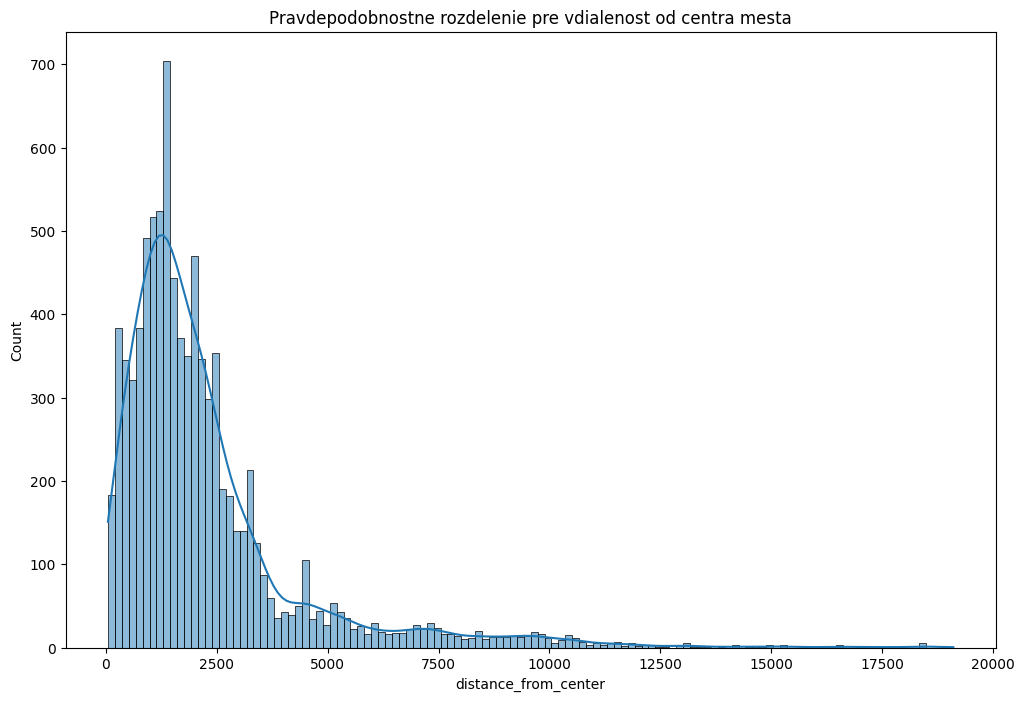

In [72]:
# vytvorenie histogramu pre zobrazenie rozdelenia vzdialenosti od centra
plt.figure(figsize=(12,8))
plt.title("Pravdepodobnostne rozdelenie pre vdialenost od centra mesta")
sb.histplot(data=listings, x="distance_from_center", kde=True)

### 4.2 Závisí cena od vzdialenosti ubytovania od centra? `[0.5b]`

Vizualizujte vzťah cena vs. vzdialenosť od centra vhodným typom grafu.

<Axes: title={'center': 'Vztah ceny ubytovania od vzdialenosti centra mesta'}, xlabel='distance_from_center', ylabel='price'>

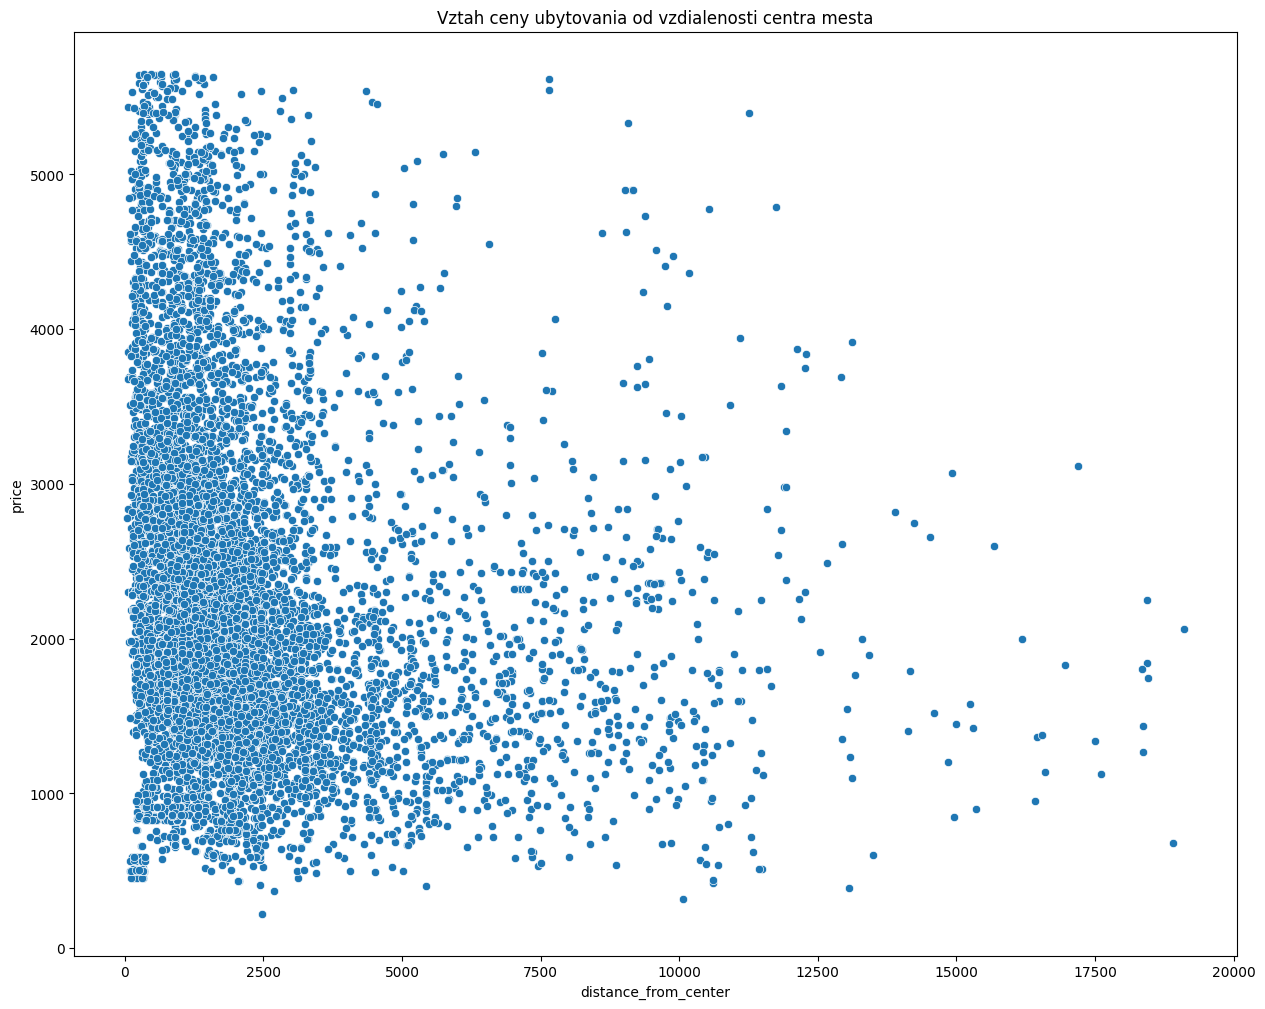

In [73]:
# graf pre porovnanie vztahu ceny ubytovania od vzdialenosti od centra mesta
plt.figure(figsize=(15,12))
plt.title("Vztah ceny ubytovania od vzdialenosti centra mesta")
sb.scatterplot(data=listings, x="distance_from_center", y="price")

### 4.3 Kde sa nachádzajú najviac recenzované ubytovania? `[1b]`

Ukážte na mape všetky ubytovania, ktoré majú počet recenzií v intervale `<500,800>` ako body, ktoré sú zafarbené podľa počtu recenzií. Zvoľte vhodnú farebnú schému, napr. nižší počet recenzií chladné farby a vyšší počet recenzií teplé farby.

**Dôležité upozornenie:** treba brať do úvahy, že sme v sekcii s čistením dát vymazali z datasetu `reviews` niektoré recenzie, t.j. údaj v datasete `listings` v stĺpci `number_of_reviews` už nie je aktuálny. Treba preto aktualizovať počty recenzií v tomto stĺpci pre jednotlivé ubytovania podľa reálneho stavu.




In [74]:
# ziskanie poctov recenzii pre kazde ubytovanie
tmp = reviews.groupby("listing_id")["listing_id"].count()
listings["number_of_reviews"] = listings["id"].map(tmp).fillna(0).astype(int)

# vyfiltrovanie len z rozsahu <500,800>
tmp = listings[(listings["number_of_reviews"] >= 500) & (listings["number_of_reviews"] <= 800)]

# prevod na stupne
tmp = tmp.to_crs('EPSG:4326')

# zobrazenie mapy ktora vizualizuje lokaciu najviac recenzovanych ubytovani v danom rozsahu
m4 = tmp.explore(
    column="number_of_reviews", # zafarbenie podla poctu recenzii v rozsahu <500,800>
    cmap="RdYlGn_r",
    legend=True,
    tooltip=["name","number_of_reviews"],
    tooltip_kwds={"style": "font-size: 28px;"},
    tiles = "CartoDB positron",
    style_kwds={"radius": 8}
)

m4.save("map4.html")

### 4.4 Ktoré slová sa najčastejšie vyskytujú v recenziách lacných/drahých ubytovaní? `[2.5b]`

O čom ľudia píšu pri lacných (menej ako 600 CZK) a drahých (viac ako 5500 CZK) ubytovaniach? Nájdite top 20 slov s dĺžkou viac ako 5 znakov pre každý typ (lacné aj drahé).

Postup (to isté platí aj pre drahé ubytovania):
1.   Získajte texty recenzií lacných ubytovaní.
1.   Zmeňte všetky písmená na malé (lowercase).
1.   Odstráňte diakritiku z textu, t.j. napr. písmeno `č` sa zmení na `c` a pod. (pomôže vám knižnica `unicodedata`)
1.   Texty recenzií rozdeľte na slová (funkcia `split`). Slovo je alfanumerická postupnosť (ne-alfanumerické znaky nesmie obsahovať) znakov oddelená od okolitého textu ľubovoľným počtom bielych znakov.
1.   Vo výsledku ponechajte len také slová, ktoré majú dĺžku viac ako **5 znakov**.
1.   Nájdite **top 20** najfrekventovanejších slov (pomôže vám knižnica `Counter`).



In [75]:
# funckia na odstranenie diaktritiky z textu
def remove_accents(input_str):

    # rozlozi znaky, napr. á -> "a" + "´"
    nfkd_form = unicodedata.normalize("NFD", input_str) 
    
    # vyfiltruje len tie ktore nie su "mark" == diakritika
    return "".join([c for c in nfkd_form if not unicodedata.combining(c)])

# spojenie tabulky reviews s tabulkou listings na nasledovne ziskanie ceny pre kazdu recenziu na zaklade toho na ake ubytovanie bola recenzia napisana
cheap_reviews = pd.merge(reviews, listings, left_on="listing_id", right_on="id", how="left")
cheap_reviews = cheap_reviews[cheap_reviews.price < 600] # vyfiltrovanie recenzii pre lacne ubytovania

cheap_reviews = cheap_reviews.comments.str.lower().reset_index() # konverzia vsetkych pismen v kazdom komentary na male pismena
cheap_reviews.comments = cheap_reviews.comments.apply(remove_accents) # aplikovanie funkcie na kazdu recenziu na zbavenie sa diakritiky v texte

text = " ".join(cheap_reviews["comments"]) # spojenie vsetkych recenzii do jedneho stringu
slova = [s for s in text.split() if (s.isalnum() & (len(s) > 5))] # vyfiltrovanie len tych slov ktore su alfaumericke a zaroven maju dlzku viac ako 5 znakov
top_20_lacne = Counter(slova).most_common(20) # namapovanie kazdemu slovu pocetnost jeho vyskytu a vyber len top 20 najpocetnejsich
top_20_lacne

[('really', 302),
 ('everything', 250),
 ('hostel', 233),
 ('location', 219),
 ('recommend', 203),
 ('prague', 182),
 ('apartment', 178),
 ('friendly', 170),
 ('perfect', 137),
 ('definitely', 133),
 ('people', 129),
 ('staying', 103),
 ('helpful', 100),
 ('station', 88),
 ('highly', 87),
 ('little', 87),
 ('center', 86),
 ('around', 80),
 ('comfortable', 79),
 ('stayed', 78)]

In [76]:
# ten isty postup ako v predchadzajucej bunke pre drahe ubytovania
expensive_reviews = pd.merge(reviews, listings, left_on="listing_id", right_on="id", how="left")
expensive_reviews = expensive_reviews[expensive_reviews.price > 5500]

expensive_reviews = expensive_reviews.comments.str.lower().reset_index()
expensive_reviews.comments = expensive_reviews.comments.apply(remove_accents)

text = " ".join(expensive_reviews["comments"])
slova = [s for s in text.split() if (s.isalnum() & (len(s) > 5))]
top_20_drahe = Counter(slova).most_common(20)
top_20_drahe

[('apartment', 1421),
 ('location', 1034),
 ('everything', 543),
 ('perfect', 510),
 ('recommend', 478),
 ('prague', 405),
 ('really', 392),
 ('highly', 317),
 ('definitely', 309),
 ('amazing', 278),
 ('beautiful', 265),
 ('spacious', 246),
 ('walking', 225),
 ('wonderful', 214),
 ('helpful', 214),
 ('comfortable', 209),
 ('communication', 199),
 ('excellent', 194),
 ('restaurants', 188),
 ('wohnung', 176)]

### 4.5 Kedy Praha najviac "žije"? `[0.5b]`

Vykreslite graf počtu recenzií podľa mesiacov v roku (do úvahy berieme všetky roky). Ktoré mesiace sú hlavná sezóna a kedy je útlm?



Praha najviac zije v hlavne letnych mesiacoch jun, jul, august.
Naopak najvacsi utlm je v zimnych mesiacoch januar, februar.


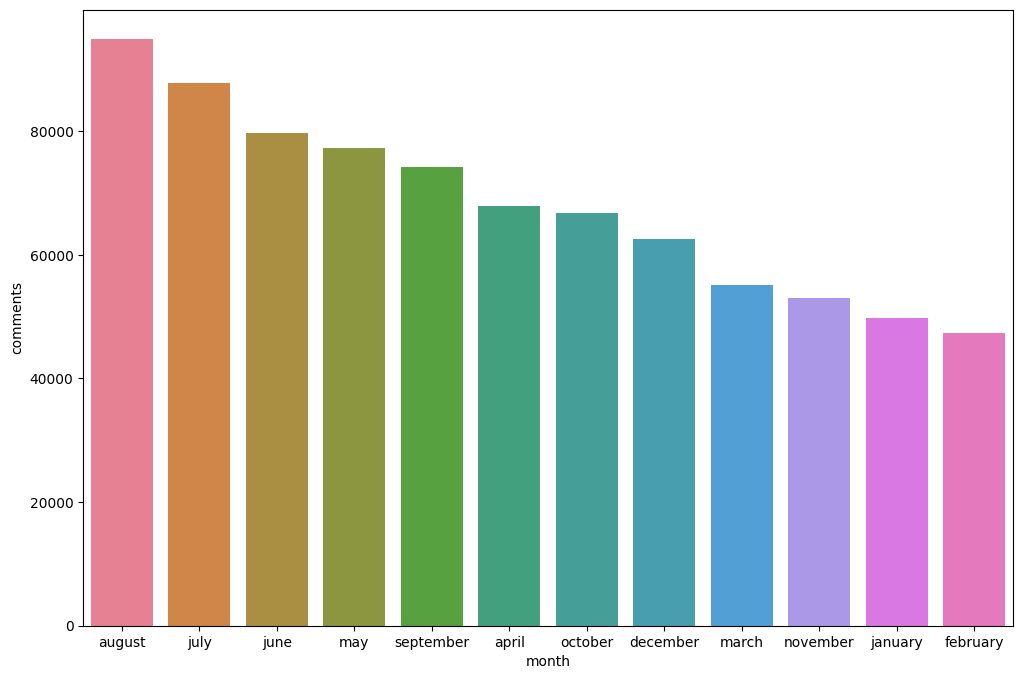

In [77]:
# novy stlpec pre mesiace
reviews["month"] = reviews["date"].dt.month.astype(str)

# namapovanie cisel na textovu reprezentaciu mesiaca
months = {"1": "january", "2": "february", "3": "march", "4": "april",
          "5": "may", "6": "june", "7": "july", "8": "august",
          "9": "september", "10": "october", "11": "november", "12": "december"}

# zoskupenie mesiacov s pocetnostou recenzii v danom mesiaci
per_month = reviews.groupby("month")["comments"].count().reset_index()
per_month["month"] = per_month["month"].map(months) # aplikacia mapovania na textovu reprezentaciu mesiaca
per_month.sort_values(by="comments", ascending=False, inplace=True)

# stlpcovy graf pre zobrazenie vztahu mesiacov vs poctu recenzii v danom mesiaci
plt.figure(figsize=(12,8))
sb.barplot(data=per_month, x="month", y="comments", hue="month")
print("Praha najviac zije v hlavne letnych mesiacoch jun, jul, august.\nNaopak najvacsi utlm je v zimnych mesiacoch januar, februar.")

### 4.6 Vplyv COVID pandémie na turizmus v Prahe `[0.5b]`

Vykreslite graf počtu recenzií v jednotlivých rokoch. Porovnajte počet recenzií v rokoch 2020-2021 s inými rokmi. Uvidíte drastický prepad a postupný návrat turizmu.


<Axes: xlabel='year', ylabel='comments'>

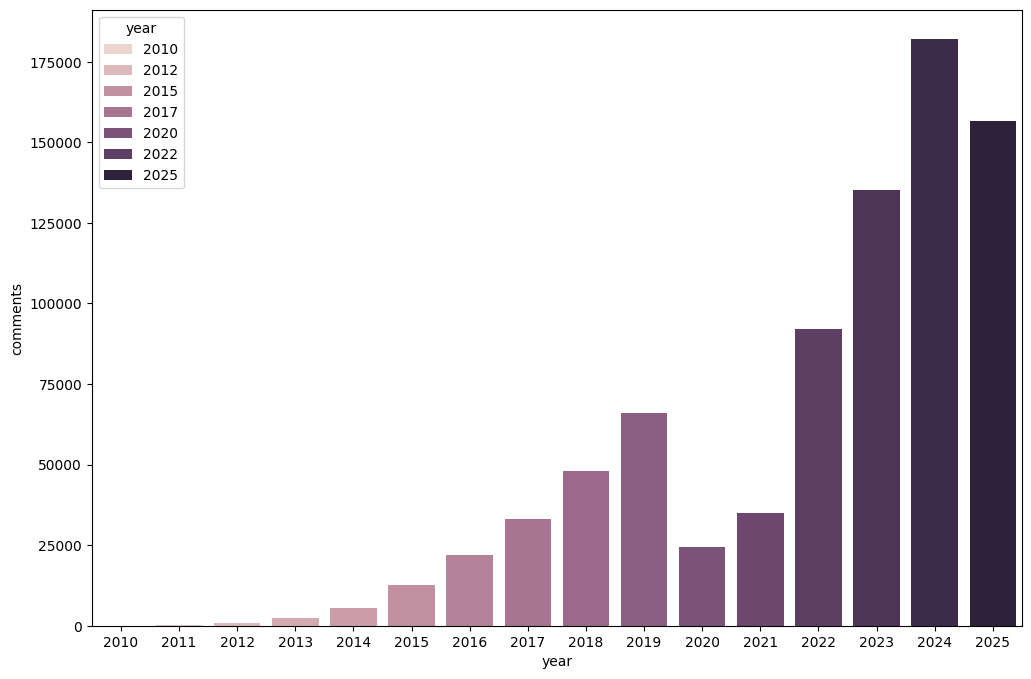

In [78]:
# novy stlpec pre rok
reviews["year"] = reviews["date"].dt.year

# zoskuenie rokov s poctom recenzii v danych rokoch
per_year = reviews.groupby("year")["comments"].count().reset_index()
per_year.sort_values(by="comments", ascending=False, inplace=True)

# vizualizacia pocetnosti recenzii v jednotlivych rokoch
plt.figure(figsize=(12,8))
sb.barplot(data=per_year, x="year", y="comments", hue="year")

### 4.7 Analýza sentimentu v dlhých recenziách v angličtine v roku 2020 `[3.5b]`

Postup:
1.    Získajte všetky recenzie **z roku 2020**, ktoré majú **viac ako 300 znakov**.
1.    V týchto recenziách vyhľadajte všetky recenzie **v anglickom jazyku**. Na detekciu jazyka použite knižnicu `fast-langdetect`. Recenziu budeme považovať za anglickú, ak detektor jazyka pre danú recenziu vypočíta skóre viac ako 80 %.
1.    Vyhodnoťte sentiment (či je pozitívna alebo negatívna) v každej recenzii napísanej v anglickom jazyku. Na výpočet sentimentu recenzie použite knižnicu `vaderSentiment`. Sentiment recenzie je vyjadrený pomocou kombinovaného skóre (tzv. `compound`), ktoré je v intervale `<-1,+1>`, pričom -1 je extrémne negatívna recenzia a +1 je extrémne pozitívna recenzia.
1.    Vypočítajte priemerný sentiment recenzií pre každú mestskú časť Prahy.
1.    Zobrazte na interaktívnej mape jednotlivé mestské časti Prahy (polygóny) a vhodne ich zafarbite podľa vypočítaného priemerného sentimentu.


In [79]:
# vyfiltrovanie recenzii z roku 2020 a zaroven ktore mali viac ako 300 znakov
reviews_2020 = reviews[(reviews.year == 2020) & (reviews.comments.str.len() > 300)]

# detekcia jazyka v ktorom je komentar napisany a nasledne priradenie detekovaneho jazyka do novrho stlpca
reviews_2020["language"] = reviews_2020["comments"].apply(lambda c: lang_detect(c)[0]["lang"])
reviews_2020["language_score"] = reviews_2020["comments"].apply(lambda c: lang_detect(c)[0]["score"]) # novy stlpec pre skore ktore udava pravdepodobnost uspesnosti spravnej detekcie
reviews_2020 = reviews_2020[(reviews_2020.language == "en") & (reviews_2020.language_score > 0.80)] # vyfiltrovanie len tych ktorych skore bolo > 0.8


analyzer = sent_analyzer() # objekt pre analyzu sentimentu

# novy stlpec pre sentiment ktory ziskame aplikaciou danej metody pre kazdu recenziu
reviews_2020["sentiment"] = reviews_2020.comments.apply(lambda c: analyzer.polarity_scores(c)["compound"])

# spojenie tabuliek aby sme ziskali prisluchajuci polygon mestskej casti na zaklade v ktorej mestskej casti bolo ubytovanie na ktore bola recenzia napisana
merged_df = pd.merge(reviews_2020, listings, left_on="listing_id", right_on="id", how="left")
merged_df = pd.merge(merged_df, neighbourhoods, on="neighbourhood", how="left")
merged_df = merged_df[["neighbourhood", "geometry", "sentiment"]]

# v sekcii 2 boli vymazane niektore ubytovania z datasetu co sposobilo ze nie kazda recenzia mala prisluchajuce ubytovanie v uz vycistenom datasete listings
# preto vymazeme tie riadky ktorym chybaju vsetky udaje (maju tam len sentiment a ostatne su NaN) v tabulke 
merged_df = merged_df.dropna(subset="neighbourhood")

# zoskupenie mestskych casti s ich priemernym sentimentom
merged_df = merged_df.groupby("neighbourhood")["sentiment"].mean().reset_index()

# spojenie tabuliek na ziskanie polygonu mestkej casti
merged_df = pd.merge(merged_df, neighbourhoods, on="neighbourhood", how="left")

# konverzia do GeoDataFramu
gdf = gpd.GeoDataFrame(
    merged_df,
    geometry="geometry",
    crs="EPSG:4326"
)

# vizualizacia mapy kde su zobrazene mestske casti a ich zafarbenie podla priemerneho sentimentu
m5 = gdf.explore(
    column="sentiment",
    cmap="RdYlGn",
    legend=True,
    tooltip=["neighbourhood", "sentiment"],
    tooltip_kwds={"style": "font-size: 28px;"},
    tiles = "CartoDB positron"
)

m5.save("map5.html")